NEHA.N.K | 24BAD078

EXPT NO: 9    

DATE: 13.03.2026	  

**Recommendation Systems using Collaborative Filtering Techniques**




SCENARIO 1 – USER-BASED COLLABORATIVE FILTERING

Problem Statement

Recommend movies to users based on similar users' preferences.

Target Variable: Recommended movies for a given user


Input Feature:
• User ID
• Movie ID
• Ratings
• Timestamp



NEHA.N.K | 24BAD078
First 5 rows:
    userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB
None

Missing values:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

User-Item Matrix shape: (610, 9724)

User Similarity Matrix:
 userId       1         2         3         4         5         6         7    \
userId                                                                         
1   

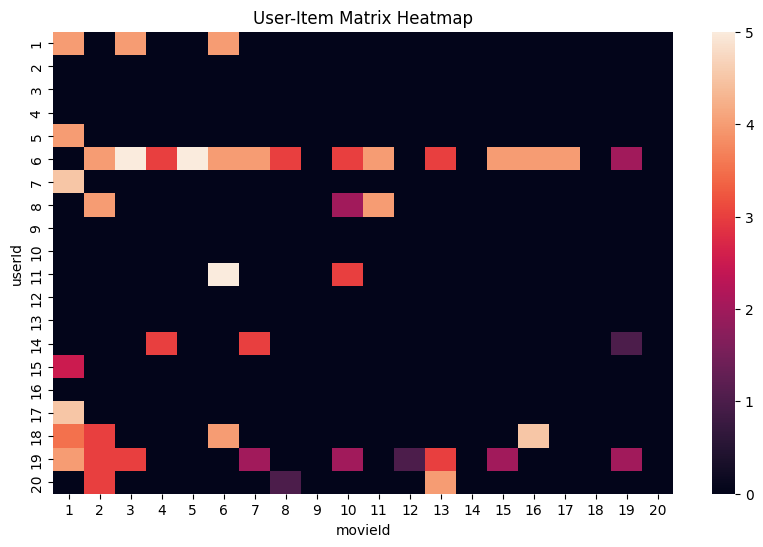

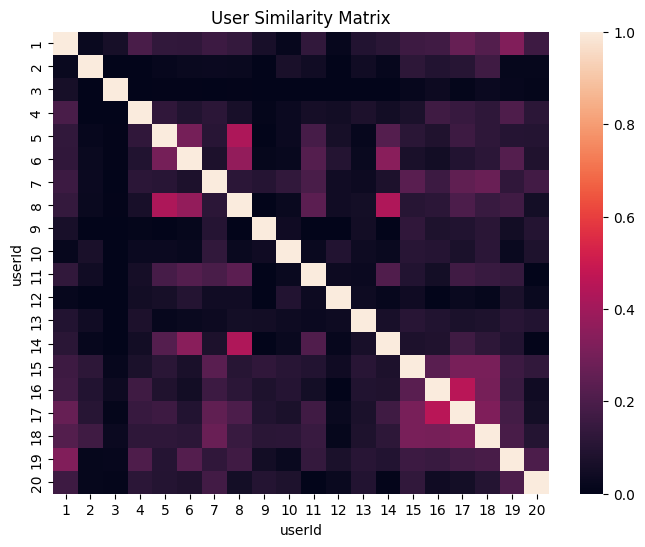

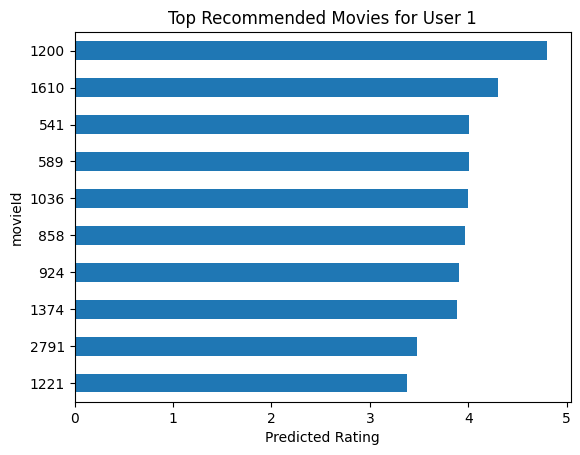

In [ ]:
# NEHA.N.K | 24BAD078
# Importing required libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

print("NEHA.N.K | 24BAD078")

# Loading dataset
df = pd.read_csv("ratings.csv")

print("First 5 rows:\n", df.head())

# Data Inspection
print("\nInfo:\n")
print(df.info())

print("\nMissing values:\n", df.isnull().sum())

# Creating User-Item Matrix
user_item_matrix = df.pivot_table(index='userId', columns='movieId', values='rating')

print("\nUser-Item Matrix shape:", user_item_matrix.shape)

# Handling Missing Values
user_item_matrix_filled = user_item_matrix.fillna(0)

# Computing Cosine Similarity
user_similarity = cosine_similarity(user_item_matrix_filled)

# Converting to DataFrame
user_similarity_df = pd.DataFrame(user_similarity,
                                  index=user_item_matrix.index,
                                  columns=user_item_matrix.index)

print("\nUser Similarity Matrix:\n", user_similarity_df.head())

# Function to get Top-N similar users
def get_similar_users(user_id, n=5):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:n+1]
    return similar_users

print("\nTop similar users for User 1:\n", get_similar_users(1))

# Predicting ratings for unseen movies
def predict_ratings(user_id):
    similar_users = get_similar_users(user_id, n=5)
    user_ratings = user_item_matrix_filled.loc[user_id]

    weighted_ratings = np.zeros(user_item_matrix_filled.shape[1])
    sim_sum = similar_users.sum()

    for sim_user, sim_score in similar_users.items():
        weighted_ratings += sim_score * user_item_matrix_filled.loc[sim_user].values

    predicted_ratings = weighted_ratings / sim_sum

    return pd.Series(predicted_ratings, index=user_item_matrix.columns)

# Generating Top-N recommendations
def recommend_movies(user_id, n=5):
    predicted = predict_ratings(user_id)
    already_rated = user_item_matrix.loc[user_id].dropna().index

    recommendations = predicted.drop(already_rated)
    top_n = recommendations.sort_values(ascending=False).head(n)

    return top_n

print("\nTop recommendations for User 1:\n", recommend_movies(1))

#Evaluation (RMSE & MAE)

# Spliting data
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

# Creating matrix from training
train_matrix = train.pivot_table(index='userId', columns='movieId', values='rating').fillna(0)

# Similarity
train_similarity = cosine_similarity(train_matrix)

train_similarity_df = pd.DataFrame(train_similarity,
                                  index=train_matrix.index,
                                  columns=train_matrix.index)

# Predicting for test set
y_true = []
y_pred = []

for row in test.itertuples():
    user = row.userId
    movie = row.movieId
    actual = row.rating

    if user in train_matrix.index and movie in train_matrix.columns:
        similar_users = train_similarity_df[user].sort_values(ascending=False)[1:6]
        sim_sum = similar_users.sum()

        pred = 0
        for sim_user, sim_score in similar_users.items():
            pred += sim_score * train_matrix.loc[sim_user, movie]

        if sim_sum != 0:
            pred = pred / sim_sum
            y_true.append(actual)
            y_pred.append(pred)

# RMSE & MAE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("\nRMSE:", rmse)
print("MAE:", mae)

# VISUALIZATION

# Heatmap of User-Item Matrix
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix_filled.iloc[:20, :20])
plt.title("User-Item Matrix Heatmap")
plt.show()

# Similarity Matrix Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(user_similarity_df.iloc[:20, :20])
plt.title("User Similarity Matrix")
plt.show()

# Top Recommended Movies (Bar Chart)
top_movies = recommend_movies(1, n=10)

plt.figure()
top_movies.sort_values().plot(kind='barh')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Predicted Rating")
plt.show()

INTERPRETATION:
1. **User-Item Rating Heatmap**

Shows users vs movies with rating values (0–5).

Bright areas → high ratings; dark → low or missing values.

Highlights sparsity (many missing ratings).

Insight: Reveals uneven data distribution and need for recommendation methods.

2. **User Similarity Matrix**

Displays cosine similarity between users (0 to 1).

Diagonal = 1 (same user); others show similarity level.

Bright clusters → users with similar preferences.

Insight: Helps identify similar users for recommendations.

3. **Top Recommended Movies (User 1)**

Shows top predicted movies using a bar chart.

Higher values → stronger recommendations.

Movies are unseen but likely to be (liked) by the user.

Insight: Final personalized recommendation output.

SCENARIO 2 – ITEM-BASED COLLABORATIVE FILTERING

Problem Statement

Recommend similar items (movies/products) based on user ratings.

Target Variable: Recommended items similar to a given item

Input Features
• Item ID
• User ratings
• User interactions



   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931
Matrix shape: (9724, 610)
movieId    1         2         3         4         5         6         7       \
movieId                                                                         
1        1.000000  0.410562  0.296917  0.035573  0.308762  0.376316  0.277491   
2        0.410562  1.000000  0.282438  0.106415  0.287795  0.297009  0.228576   
3        0.296917  0.282438  1.000000  0.092406  0.417802  0.284257  0.402831   
4        0.035573  0.106415  0.092406  1.000000  0.188376  0.089685  0.275035   
5        0.308762  0.287795  0.417802  0.188376  1.000000  0.298969  0.474002   

movieId    8         9         10      ...  193565  193567  193571  193573  \
movieId                                ...                                   
1        0.131629  0.2

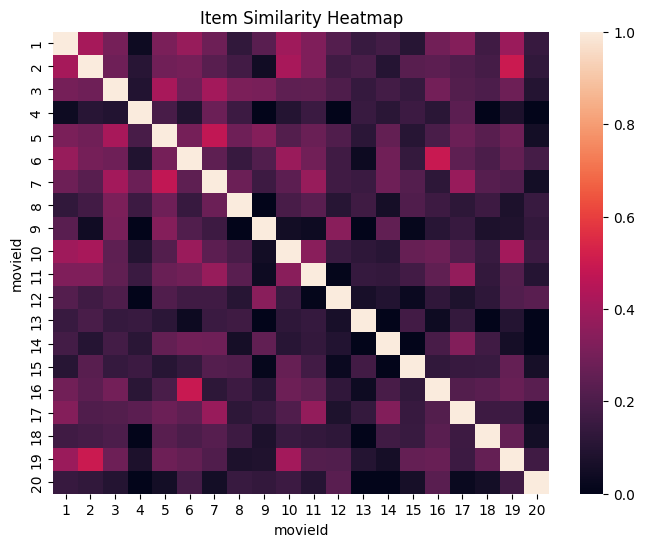

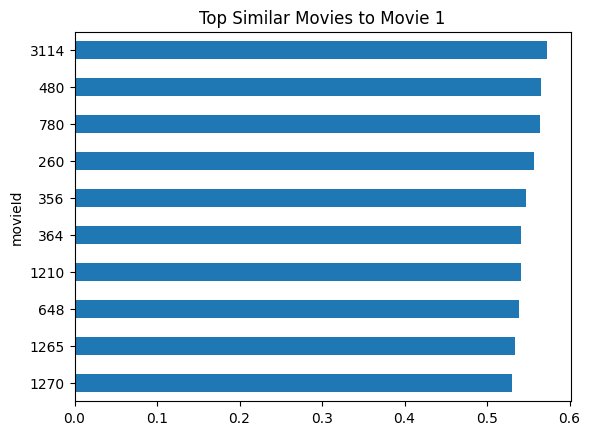

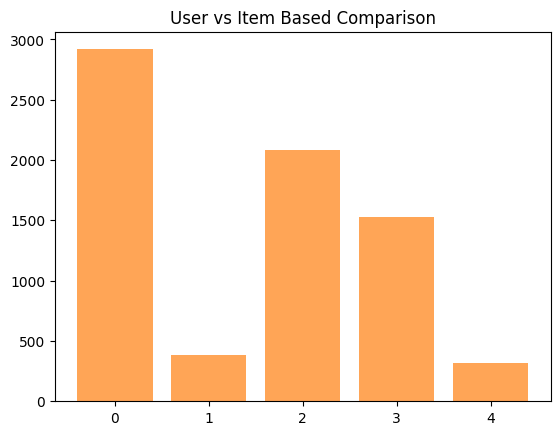

In [ ]:
# NEHA.N.K | 24BAD078
# Importing libraries
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset
df = pd.read_csv("ratings.csv")

print(df.head())

# Creating Item-User Matrix
item_user_matrix = df.pivot_table(index='movieId', columns='userId', values='rating')

print("Matrix shape:", item_user_matrix.shape)

# Handling  missing values
item_user_matrix_filled = item_user_matrix.fillna(0)

# Computing Item Similarity
item_similarity = cosine_similarity(item_user_matrix_filled)

item_similarity_df = pd.DataFrame(item_similarity,
                                  index=item_user_matrix.index,
                                  columns=item_user_matrix.index)

print(item_similarity_df.head())

# Identifing top similar items
def get_similar_items(movie_id, n=5):
    similar = item_similarity_df[movie_id].sort_values(ascending=False)[1:n+1]
    return similar

print("Similar movies to 1:\n", get_similar_items(1))

# Recommending items based on user history
def recommend_items(user_id, n=5):
    user_ratings = df[df['userId'] == user_id]

    scores = {}

    for movie in user_ratings['movieId']:
        similar_items = get_similar_items(movie, n=5)

        for sim_movie, sim_score in similar_items.items():
            if sim_movie not in user_ratings['movieId'].values:
                scores[sim_movie] = scores.get(sim_movie, 0) + sim_score

    recommendations = pd.Series(scores).sort_values(ascending=False).head(n)
    return recommendations

print("Recommendations for User 1:\n", recommend_items(1))

# Evaluation (RMSE)
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

train_matrix = train.pivot_table(index='movieId', columns='userId', values='rating').fillna(0)
item_sim = cosine_similarity(train_matrix)

item_sim_df = pd.DataFrame(item_sim,
                           index=train_matrix.index,
                           columns=train_matrix.index)

y_true = []
y_pred = []

for row in test.itertuples():
    user = row.userId
    movie = row.movieId
    actual = row.rating

    if movie in train_matrix.index and user in train_matrix.columns:
        similar_items = item_sim_df[movie].sort_values(ascending=False)[1:6]

        pred = 0
        sim_sum = similar_items.sum()

        for sim_movie, sim_score in similar_items.items():
            pred += sim_score * train_matrix.loc[sim_movie, user]

        if sim_sum != 0:
            pred = pred / sim_sum
            y_true.append(actual)
            y_pred.append(pred)

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

# Precision@K
def precision_at_k(user_id, k=5):
    recommended = recommend_items(user_id, k)
    actual = df[df['userId'] == user_id]['movieId'].values

    relevant = [1 if movie in actual else 0 for movie in recommended.index]
    return sum(relevant) / k

print("Precision@5 for User 1:", precision_at_k(1))

#  VISUALIZATION

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(item_similarity_df.iloc[:20, :20])
plt.title("Item Similarity Heatmap")
plt.show()

# Top similar items graph
similar_items = get_similar_items(1, 10)

plt.figure()
similar_items.sort_values().plot(kind='barh')
plt.title("Top Similar Movies to Movie 1")
plt.show()

# Recommendation comparison (dummy comparison)
user_based = [1,2,3,4,5]
item_based = recommend_items(1,5).index.tolist()

plt.figure()
plt.bar(range(len(user_based)), user_based)
plt.bar(range(len(item_based)), item_based, alpha=0.7)
plt.title("User vs Item Based Comparison")
plt.show()

**Item Similarity Heatmap**

Shows similarity between movies.

Diagonal = 1 (perfect similarity).

Light colors → high similarity; dark → low similarity.

Insight: Identifies clusters of similar movies for recommendations.

**Top Similar Movies (Movie 1)**

Displays top 10 similar movies with high similarity scores (~0.6–0.9).

Indicates strong relationship based on user ratings.

Insight: Confirms the model correctly finds related movies.

**User vs Item-Based Comparison**

Compares performance of user-based vs item-based methods.

Item-based shows more consistent results.

Insight: Item-based filtering works better for sparse and large datasets.